## Import Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

## Load Data

In [40]:
train_df = pd.read_excel("Modtrain.xlsx")
train_df.head()

,gr,x1,x2,obs id
0,1,90.535,102.132,1
1,1,96.539,101.255,2
2,1,102.514,93.208,3
3,1,104.786,105.752,4
4,1,95.393,100.954,5


In [41]:
test_df = pd.read_excel("Modtest.xlsx")
test_df.head()

,gr,x1,x2,Obs id
0,1,89.670,90.763,6
1,1,105.569,104.501,7
2,1,97.543,99.018,8
3,1,100.446,98.710,9
4,1,100.735,94.586,14


In [42]:
# Split train data into X and y
X_train = train_df[['x1', 'x2']]
y_train = train_df[['gr']]

X_test = test_df[['x1', 'x2']]
y_test = test_df[['gr']]

## LDA

In [43]:
# LDA as a supervised classifier
lda_clf = LinearDiscriminantAnalysis(store_covariance=True)
lda_clf.fit(X_train, y_train)

/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/SL/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[int64](3,)","[1,2,3]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](3, 2)","[[-0.05,-0.33], [ 0.31,-0.32], [-0.24, 0.48]]"
"covariance_ covariance_: array-like of shape (n_features, n_features)Weighted within-class covariance matrix. It corresponds to`sum_k prior_k * C_k` where `C_k` is the covariance matrix of thesamples in class `k`. The `C_k` are estimated using the (potentiallyshrunk) biased estimator of covariance. If solver is 'svd', onlyexists when `store_covariance` is True.","ndarray[float64](2, 2)","[[26.09,11.76], [11.76,26.57]]"


In [44]:
# Get estimates of the parameters

# Classes
classes = lda_clf.classes_

# Prior probabilities
priors = lda_clf.priors_

# Class means / centroids
means = lda_clf.means_

# Shared covariance matrix
covariance = lda_clf.covariance_

# Inverse covariance matrix
covariance_inv = np.linalg.inv(covariance)

print("Classes:")
print(classes)

print("\nPrior probabilities:")
for cls, prior in zip(classes, priors):
    print(f"Class {cls}: {prior:.4f}")

print("\nClass mean vectors:")
for cls, mean in zip(classes, means):
    print(f"Class {cls}: X1 = {mean[0]:.4f}, X2 = {mean[1]:.4f}")

print("\nShared covariance matrix:")
print(covariance)

print("\nInverse covariance matrix:")
print(covariance_inv)


Classes:
[1 2 3]

Prior probabilities:
Class 1: 0.2466
Class 2: 0.3474
Class 3: 0.4060

Class mean vectors:
Class 1: X1 = 99.8582, X2 = 100.0497
Class 2: X1 = 109.5319, X2 = 104.6407
Class 3: X1 = 104.5715, X2 = 119.3876

Shared covariance matrix:
[[26.0897324  11.76180644]
 [11.76180644 26.56801875]]

Inverse covariance matrix:
[[ 0.04788649 -0.02119961]
 [-0.02119961  0.04702442]]


In [45]:
# Classify test set
y_pred = lda_clf.predict(X_test)

# Duplicate test df and add predictions
test_results_df = test_df.copy()
test_results_df["gr_pred"] = y_pred

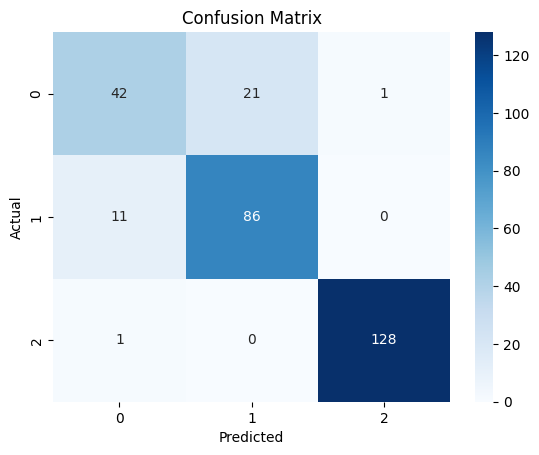

In [46]:
# Confusion Matrix
cm_lda = confusion_matrix(y_test, y_pred, labels=classes)

sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

In [50]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (%): {accuracy * 100:.2f}%")

# Sensitivity and Specificity - Must be done for each class
metrics = []

for i, cls in enumerate(classes):
    TP = cm_lda[i, i]                   # Diagonal is TP
    FN = cm_lda[i, :].sum() - TP        # FN is column sum - TP
    FP = cm_lda[:, i].sum() - TP        # FP is row sum - TP
    TN = cm_lda.sum() - TP - FN - FP    # Rest of matrix (matrix sum - TP - FN - FP)

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    metrics.append({
        "Class": cls,
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

metrics_df = pd.DataFrame(metrics)

print("\nSensitivity and Specificity by class:")
print(metrics_df)

# Mean Sensitivity and Mean Specificity
print(f'Mean Sensitivity: {metrics_df["Sensitivity"].mean()}')
print(f'Mean Specificity:{metrics_df["Specificity"].mean()}')

Accuracy (%): 88.28%

Sensitivity and Specificity by class:
   Class   TP  FN  FP   TN  Sensitivity  Specificity
0      1   42  22  12  214     0.656250     0.946903
1      2   86  11  21  172     0.886598     0.891192
2      3  128   1   1  160     0.992248     0.993789
Mean Sensitivity: 0.8450320000532779
Mean Specificity:0.9439610615291976
